# US Equities Panel: Label Engineering

Every model in this case study is trained to predict the label defined here, so an error in
it is silent where it is made and reaches every metric and every backtest after it. This
notebook fixes the execution convention, proves each labelled row has a complete forward
window inside one symbol, measures how much independent information those rows carry,
establishes the floor a feature has to clear, and writes the files stage 03 reads.

## Learning objectives

- Express a forward return as an execution convention, then assert - rather than describe -
  that every labelled window is complete and gap-free inside one symbol
- Keep an eligibility screen away from the forward shift, and apply it where it cannot change
  the window of a row it keeps
- Seal a diagnostic on the label's endpoint rather than on its observation date
- Price the overlap in a multi-session label, both as decay and as an effective row count
- Establish the floor a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the split- and dividend-adjusted daily panel through
`load_us_equities()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the label set, the horizons and the holdout boundary.
Writes `labels/fwd_ret_1d.parquet`, `labels/fwd_ret_5d.parquet` and
`labels/fwd_ret_21d.parquet`, each with a `.digest.json` sidecar beside it.
`03_financial_features.py` reads `fwd_ret_1d.parquet`, which it names directly; the model
stages read the variants through `labels.variants`.

In [1]:
"""US Equities Panel: Label Engineering."""

import math
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_us_equities
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "us_equities_panel"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

`START_DATE` trims the history to a later start, which is what shortens a run in CI. It is read
once below, and it costs more than the sessions it removes: the eligibility screen needs a month
of trailing volume, so the first sessions after the new start carry no eligible stock at all, and
Section E's dispersion and Section G's rank correlation both need a wide cross-section to mean
anything.

In [2]:
START_DATE = "1990-01-01"

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A horizon
or a boundary typed into a cell is a second copy of a value the rest of the pipeline reads
from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` prefers an explicit `labels.horizons` entry and falls back to the
cross-validation buffer. The two fields are separate, because the gap that keeps folds
independent need not equal the horizon an outcome resolves over; here they coincide, and
both are declared in trading sessions.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in LABEL_NAMES
}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
END_DATE = setup["evaluation"]["holdout_end"]

# The tradability screen, Section B. `03_financial_features` carries the same three constants
# and rebuilds the screen from them.
MIN_PRICE, MIN_ADV_USD, ADV_WINDOW = 5.0, 1_000_000, 21

print(f"Labels: {LABEL_NAMES}, primary {PRIMARY_LABEL}, horizons {HORIZONS} sessions")
print(f"Holdout opens {HOLDOUT_START} and seals the label endpoint; panel ends {END_DATE}")

Labels: ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_21d'], primary fwd_ret_1d, horizons {'fwd_ret_1d': 1, 'fwd_ret_5d': 5, 'fwd_ret_21d': 21} sessions
Holdout opens 2016-01-01 and seals the label endpoint; panel ends 2018-03-31


## A. The learning task

The hypothesis is cross-sectional and it is about breadth. No single US stock carries much
predictable return, but the panel is wide, and the Fundamental Law of Active Management says
a weak per-stock edge applied across thousands of names can still add up to a portfolio-level
one. The claim to test is that stocks can be ranked against each other on the strength of
their recent price history, so the label is a forward price return and the strategy that
consumes it is long-short across the deciles of that ranking.

The decision cadence comes from `setup.yaml`: the position is decided at a daily close and
entered at the next open. That fixes the primary horizon at one session, which is also the
horizon with the least overlap and therefore the most independent rows. The weekly and
monthly variants ask whether the same ranking still pays when the book turns over a fifth
and a twentieth as often - a question about cost and turnover rather than a second
hypothesis.

## B. Preparation before the label

A forward window is meaningful only on a price series that is adjusted, ordered and complete.
`adj_close` carries the split and dividend adjustment, so a return taken across a split does
not register the split as a price move; sorting by `symbol` then `timestamp` is what makes a
shift mean "the next session for this stock".

This case study screens its universe for tradability: a stock enters on a date only if its
adjusted close is above five dollars and its dollar volume averaged more than a million a day
over the previous month. Both are rolling backward windows, and
[`03_financial_features`](03_financial_features.ipynb) rebuilds the screen from the same three
constants on the same price series, so the trainable panel and these files agree on the universe.

**The screen runs after the forward shift, not before, and that ordering is not a detail.**
Once ineligible rows are dropped a shift counts survivors instead of sessions: a stock that
falls below either threshold and recovers carries a label spanning the whole excursion,
reported as a one-session return. The screen removes whole rows and never changes the window
of a row it keeps, so applying it afterwards leaves the same eligible universe with labels
measured over the sessions they claim. Section D applies it, once every window is verified.

In [4]:
prices = load_us_equities(start_date=START_DATE, end_date=END_DATE)
if prices.schema["timestamp"] == pl.Datetime:
    prices = prices.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
prices = prices.sort(["symbol", "timestamp"])

# Recorded as every label's `inputs`: a re-run against a refreshed download is otherwise
# indistinguishable from this one. Volume is in the digest because it decides which rows are
# written, so a corrected volume moves the artifact without the price having changed.
MARKET_DATA_DIGEST = value_digest(prices, ["symbol", "timestamp", "adj_close", "adj_volume"])

print(f"{prices['symbol'].n_unique():,} symbols, {prices.height:,} symbol-sessions")
print(f"Sessions {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"market_data digest: {MARKET_DATA_DIGEST}")

3,199 symbols, 14,498,930 symbol-sessions
Sessions 1990-01-02 to 2018-03-27
market_data digest: 33e8551b7b4367ae


## C. Label construction

One execution convention, written once and applied at all three horizons:

$$r^{(h)}_{i,t} = \frac{P_{i,t+h}}{P_{i,t}} - 1$$

where $P$ is the adjusted close of stock $i$ and $t+h$ counts $h$ **trading sessions in that
stock's own series**: Chapter 7.2's close-to-close convention. It is not the convention the
backtest fills at - `setup.yaml` places execution at the next open - and that difference is a
real gap, left to [`18_costs`](18_costs.ipynb), which sweeps commission and spread rather
than the return definition.

A window is kept only where it spans no more calendar time than $h$ sessions of a
five-session week plus a week of exchange holidays. The panel holds stocks that stop trading
for months and resume under the same ticker, and without that rule the shift closes over the
hole and reports a multi-year price change as a one-session return.

Two bookkeeping columns are numbered here, on the complete price series, because both mean
something only before a row is dropped: `from_end` counts back from each stock's last session
for Section D's boundary profile, and `session` numbers its sessions forward so Section F's
overlap statistics keep counting sessions once the null tail and the holdout are filtered
out. Neither reaches a label parquet, which selects three columns.

In [5]:
def window_span(horizon: int) -> pl.Expr:
    """Calendar days the forward window covers, within one symbol."""
    return (
        pl.col("timestamp").shift(-horizon).over("symbol") - pl.col("timestamp")
    ).dt.total_days()


def span_tolerance(horizon: int) -> int:
    """Widest calendar span holidays alone can explain for a `horizon`-session window."""
    return math.ceil(horizon * 7 / 5) + 7


def forward_return(df: pl.DataFrame, horizon: int, name: str) -> pl.DataFrame:
    """Close-to-close return over `horizon` sessions, null where the window spans a hole."""
    return df.with_columns(
        pl.when(window_span(horizon) <= span_tolerance(horizon))
        .then(pl.col("adj_close").shift(-horizon).over("symbol") / pl.col("adj_close") - 1)
        .otherwise(None)
        .alias(name)
    )


labels_df = prices.with_columns(
    (pl.len().over("symbol") - 1 - pl.int_range(pl.len()).over("symbol")).alias("from_end"),
    pl.int_range(pl.len()).over("symbol").alias("session"),
)
for label_name, horizon in HORIZONS.items():
    labels_df = forward_return(labels_df, horizon, label_name)

print(f"Constructed {', '.join(LABEL_NAMES)}")
print(
    "Span tolerance per horizon, calendar days: "
    + ", ".join(f"{h} sessions -> {span_tolerance(h)}d" for h in HORIZONS.values())
)

Constructed fwd_ret_1d, fwd_ret_5d, fwd_ret_21d
Span tolerance per horizon, calendar days: 1 sessions -> 9d, 5 sessions -> 14d, 21 sessions -> 37d


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity the
label claims. Each property below fails silently and leaves plausible numbers behind, so each
is asserted rather than described.

The third assertion is a full reconciliation rather than a bound. Every row carrying no label
is attributed to exactly one cause - the tail of its stock's series, a hole inside the forward
window, or a missing price at one end of it - and the four counts have to sum to the height of
the frame. A label crossing a symbol boundary, or a short label masked by a longer one's null
set, would break that identity, and on this panel the second is the likelier failure: the
monthly label is null on twenty more rows per stock than the daily one, and a single shared
`drop_nulls` would silently trim the daily file to the monthly one's support.

In [6]:
for label_name, horizon in HORIZONS.items():
    tolerance = span_tolerance(horizon)
    checked = labels_df.with_columns(window_span(horizon).alias("_span"))
    tail = pl.col("from_end") < horizon
    holed = ~tail & (pl.col("_span") > tolerance)
    end_price = pl.col("adj_close").shift(-horizon).over("symbol")
    unpriced = ~tail & ~holed & (pl.col("adj_close").is_null() | end_price.is_null())
    causes = {"tail": tail, "hole in window": holed, "no price at an end": unpriced}
    labelled = checked.drop_nulls(label_name)

    # 1. An incomplete forward window is null, never a value.
    assert checked.filter(tail)[label_name].null_count() == checked.filter(tail).height

    # 2. No labelled window spans more calendar days than holidays alone can explain.
    assert labelled.filter(pl.col("_span") > tolerance).height == 0, label_name

    # 3. Labelled rows plus the three causes account for every row, each cause once.
    counts = {cause: checked.filter(cond).height for cause, cond in causes.items()}
    assert labelled.height + sum(counts.values()) == checked.height, (label_name, counts)

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert labels_df.schema[label_name] == pl.Float64, label_name

    unlabelled = ", ".join(f"{n:,} {cause}" for cause, n in counts.items())
    print(
        f"{label_name}: {labelled.height:,} labelled, spans up to {labelled['_span'].max()}d "
        f"against a {tolerance}d tolerance; unlabelled {unlabelled}"
    )

fwd_ret_1d: 14,495,643 labelled, spans up to 9d against a 9d tolerance; unlabelled 3,199 tail, 86 hole in window, 2 no price at an end


fwd_ret_5d: 14,482,388 labelled, spans up to 14d against a 14d tolerance; unlabelled 15,994 tail, 546 hole in window, 2 no price at an end


fwd_ret_21d: 14,421,381 labelled, spans up to 37d against a 37d tolerance; unlabelled 67,148 tail, 10,399 hole in window, 2 no price at an end


Position zero below is each stock's last session. The non-null rate has to fall to zero over
exactly the last `horizon` positions and be flat beyond them. A scalar count of valid rows shows
neither failure this catches: a tail fabricated instead of nulled, or a short label masked by a
longer one's null set. The flat stretch sits just under one rather than at it, because a stock
whose series ends in a suspension carries nulls further in than its horizon. The figure reads
only the null structure and never a value, so it is not sealed, and it is drawn before the
eligibility screen because the screen removes whole rows rather than nulling them.

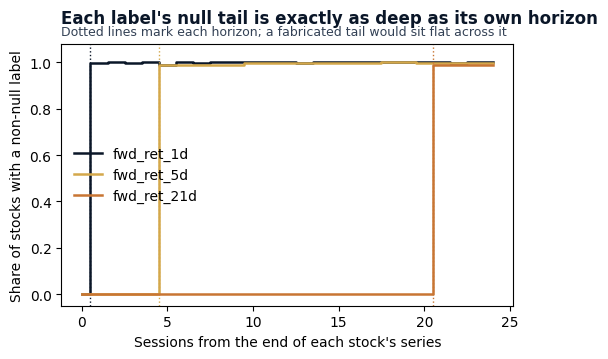

In [7]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZONS.values()) + 3)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"], COLORS["copper"])):
    ax.step(profile["from_end"], profile[name], where="mid", color=colour, lw=1.8, label=name)
    ax.axvline(HORIZONS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Sessions from the end of each stock's series")
ax.set_ylabel("Share of stocks with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Each label's null tail is exactly as deep as its own horizon",
    subtitle="Dotted lines mark each horizon; a fabricated tail would sit flat across it",
)
ax.legend(loc="center left", frameon=False)
show_with_alt(fig, "Non-null label rate by position from the end of each stock's series.")

The eligibility screen declared in Section B is applied here, on the frame whose windows the
assertions above have just fixed. `session` keeps numbering the complete series, so the
stretches the screen removes stay visible as gaps to Section F rather than closing up; that is
the grid the overlap statistics have to be counted on.

In [8]:
eligible = labels_df.with_columns(
    (pl.col("adj_close") * pl.col("adj_volume"))
    .rolling_mean(ADV_WINDOW)
    .over("symbol")
    .alias("adv_21d")
).filter((pl.col("adj_close") > MIN_PRICE) & (pl.col("adv_21d") > MIN_ADV_USD))

print(
    f"Eligible: {eligible.height:,} of {labels_df.height:,} symbol-sessions "
    f"({eligible.height / labels_df.height:.1%}), {eligible['symbol'].n_unique():,} stocks"
)

Eligible: 9,275,123 of 14,498,930 symbol-sessions (64.0%), 3,173 stocks


## E. Distribution and base rate

What scale is the label, and does it mean the same thing across stocks and across regimes?
Everything from here through Section G is computed on the development window only, sealed on
the label's **endpoint** rather than its observation date: a row observed shortly before the
holdout still resolves inside it, so a filter on the observation date looks sealed and is not.
The label files keep every eligible row, holdout included, because the seal governs what this
notebook looks at rather than what it writes.

In [9]:
dev = {}
for label_name, horizon in HORIZONS.items():
    # The endpoint is a property of the label, so it is derived on the complete series the label
    # was built on. Shifting the screened frame instead would return the horizon-th next eligible
    # row, which is a later date and depends on eligibility after the decision.
    ends = labels_df.select(
        "symbol",
        "timestamp",
        pl.col("timestamp").shift(-horizon).over("symbol").alias("_label_end"),
    )
    dev[label_name] = (
        eligible.join(ends, on=["symbol", "timestamp"], how="left")
        .filter(pl.col("_label_end") < HOLDOUT_START)
        .drop_nulls(label_name)
    )
    frame = dev[label_name]
    print(f"{label_name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

fwd_ret_1d: 8,058,076 development rows through 2015-12-30


fwd_ret_5d: 8,047,838 development rows through 2015-12-23


fwd_ret_21d: 8,002,727 development rows through 2015-12-01


All three labels go on one axis with identical bins and a logarithmic count axis. The claim
the figure has to support is about shape rather than width - three dispersion scalars would
carry the width, and they are printed below - and the shape here is that the longer horizons
move mass out of the centre into both tails rather than spreading the body evenly. The axis
is symmetric and narrower than any label's range, so rows outside it are counted below rather
than drawn.

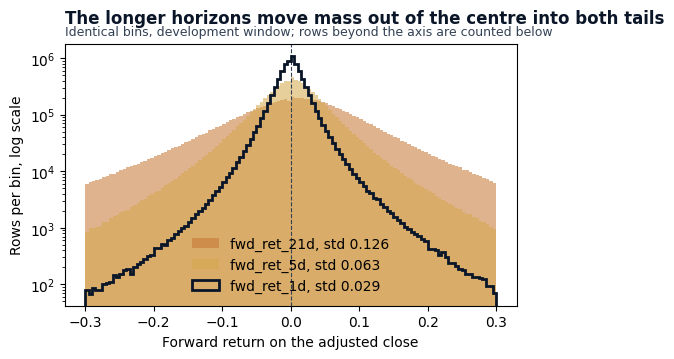

fwd_ret_1d: std 0.02904, 1.00x the primary label against 1.00 under square-root-of-horizon scaling, kurtosis 101.8, 1,199 left and 1,344 right of the axis
fwd_ret_5d: std 0.06312, 2.17x the primary label against 2.24 under square-root-of-horizon scaling, kurtosis 44.1, 12,740 left and 17,336 right of the axis
fwd_ret_21d: std 0.12579, 4.33x the primary label against 4.58 under square-root-of-horizon scaling, kurtosis 25.2, 113,712 left and 138,776 right of the axis


In [10]:
bins = np.linspace(-0.30, 0.30, 121)
styles = [
    dict(color=COLORS["copper"], alpha=0.55, zorder=1),
    dict(color=COLORS["amber"], alpha=0.55, zorder=2),
    dict(color=COLORS["blue"], histtype="step", lw=2, zorder=3),
]
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, style in zip(reversed(LABEL_NAMES), styles):
    series = dev[name][name]
    ax.hist(series.to_numpy(), bins=bins, label=f"{name}, std {series.std():.3f}", **style)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Forward return on the adjusted close")
ax.set_ylabel("Rows per bin, log scale")
add_message_title(
    ax,
    "The longer horizons move mass out of the centre into both tails",
    subtitle="Identical bins, development window; rows beyond the axis are counted below",
)
ax.legend(loc="lower center", frameon=False)
show_with_alt(fig, "Histograms of all three labels on identical bins and a log count axis.")

std = {name: dev[name][name].std() for name in LABEL_NAMES}
for name in LABEL_NAMES:
    frame, column = dev[name], pl.col(name)
    out = frame.filter(column < bins[0]).height, frame.filter(column > bins[-1]).height
    root_h = math.sqrt(HORIZONS[name] / PRIMARY_HORIZON)
    print(
        f"{name}: std {std[name]:.5f}, {std[name] / std[PRIMARY_LABEL]:.2f}x the primary label "
        f"against {root_h:.2f} under square-root-of-horizon scaling, kurtosis "
        f"{frame[name].kurtosis():.1f}, {out[0]:,} left and {out[1]:,} right of the axis"
    )

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label ranked
across a cross-section, the quantity that has to be stable is the spread the model ranks
within: where it is not, the same rank correlation buys a different amount of return. The spread
is taken across stocks on each session first and only then averaged over the year, because
pooling a whole year of stock-sessions into one standard deviation would add the movement of the
panel's own mean from session to session to the spread a ranking model is actually scored on.

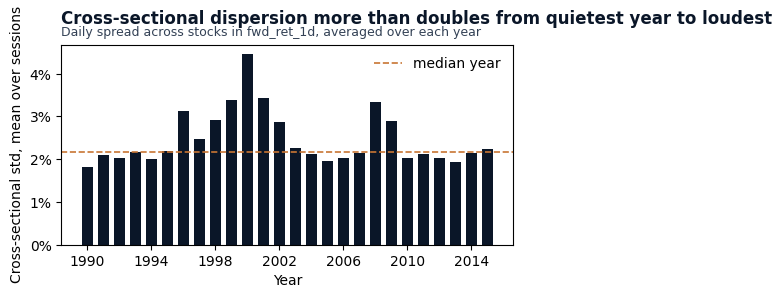

dispersion peaks at 4.46% in 2000 against 1.81% in 1990, a ratio of 2.46; median year 2.17%


In [11]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean())
    .sort("year")
)
peak, low = (annual.sort("dispersion", descending=d).row(0, named=True) for d in (True, False))
median_dispersion = annual["dispersion"].median()

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.7)
ax.axhline(median_dispersion, color=COLORS["copper"], linestyle="--", lw=1.2, label="median year")
ax.set_xticks(annual["year"].to_list()[::4])
ax.set_xlabel("Year")
ax.set_ylabel("Cross-sectional std, mean over sessions")
format_pct_axis(ax)
add_message_title(
    ax,
    "Cross-sectional dispersion more than doubles from quietest year to loudest",
    subtitle=f"Daily spread across stocks in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-sectional dispersion of the primary label.")

print(
    f"dispersion peaks at {peak['dispersion']:.2%} in {peak['year']:.0f} against "
    f"{low['dispersion']:.2%} in {low['year']:.0f}, a ratio of "
    f"{peak['dispersion'] / low['dispersion']:.2f}; median year {median_dispersion:.2%}"
)

On the development window the daily label has a standard deviation of 0.02904, the weekly
0.06312 and the monthly 0.12579 - 2.17x and 4.33x the daily one, against the 2.24x and 4.58x
square-root-of-horizon scaling implies, so the longer horizons come out slightly narrower than
a run of independent daily moves would make them. Their tails are the other way round: excess
kurtosis falls from 101.8 on the daily label to 25.2 on the monthly one, because a month of
returns averages away the single-session jumps that dominate the daily tail. The spread a
ranking model works inside is not stable through time: cross-sectional dispersion peaks at
4.46% in 2000 against 1.81% in 1990, a ratio of 2.46, with a median year of 2.17%.

## F. Overlap and effective sample size

Sampling a multi-session label at every session makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is priced
in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting per stock,
because concurrency is a property of one stock's own overlapping windows.

Both are counted on `session`, the grid the label was built on, rather than on position among
the rows that survive to the development frame. Closing over a suspension would pair windows
that share nothing and report the overlap as larger than it is.

The daily label is the case that fixes the arithmetic: consecutive one-session forward returns
are built from disjoint returns, so its effective count has to come back equal to its row
count exactly. A window that counted its anchor bar as consumed would halve it instead.

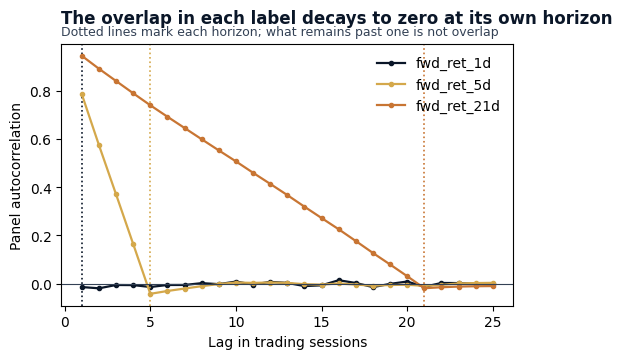

fwd_ret_1d: N=8,058,076, N_eff=8,058,076, ratio 1.0000 against 1.0000 for windows overlapping this fully; autocorrelation -0.014 at lag one, -0.014 at its horizon


fwd_ret_5d: N=8,047,838, N_eff=1,635,506, ratio 0.2032 against 0.2000 for windows overlapping this fully; autocorrelation 0.785 at lag one, -0.042 at its horizon


fwd_ret_21d: N=8,002,727, N_eff=402,359, ratio 0.0503 against 0.0476 for windows overlapping this fully; autocorrelation 0.944 at lag one, -0.019 at its horizon


In [12]:
max_lag = max(HORIZONS.values()) + 4
acf = {
    name: panel_autocorrelation(dev[name], name, max_lag=max_lag, bar_col="session")
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name, colour in zip(LABEL_NAMES, (COLORS["blue"], COLORS["amber"], COLORS["copper"])):
    ax.plot(lags, acf[name], "o-", ms=3, c=colour, lw=1.6, label=name)
    ax.axvline(HORIZONS[name], color=colour, linestyle=":", lw=1.2)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in trading sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "The overlap in each label decays to zero at its own horizon",
    subtitle="Dotted lines mark each horizon; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of all three labels against lag in trading sessions.")

# A horizon-h label consumes the h returns realised over its window, and its neighbour one
# session later shares h-1 of them, so average uniqueness converges to 1/h.
for label_name, horizon in HORIZONS.items():
    n_rows, n_eff = effective_sample_size(dev[label_name], horizon=horizon, bar_col="session")
    print(
        f"{label_name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / horizon:.4f} for windows overlapping this fully; autocorrelation "
        f"{acf[label_name][0]:.3f} at lag one, {acf[label_name][horizon - 1]:.3f} at its horizon"
    )

The daily label's 8,058,076 development rows carry 8,058,076 effective observations, a ratio of
exactly 1.0000, as disjoint one-session windows require. The weekly label's 8,047,838 rows carry
1,635,506, a ratio of 0.2032 against the 0.2000 a fully overlapped five-session window implies,
and the monthly label's 8,002,727 rows carry 402,359, a ratio of 0.0503 against 0.0476. Both
variants sit above their reference value because a stock dropping out of the eligible universe
ends an overlap early. Autocorrelation at lag one is -0.014 for the daily label, 0.785 for the
weekly and 0.944 for the monthly, and the two variants fall to -0.042 and -0.019 at their own
horizons. So the monthly label buys twenty times the rows of a monthly sample and roughly one
twentieth of the evidence per row. The purge gap a fold needs is set by the forward window
itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the skip-month momentum the case study's hypothesis names, the return from
twelve months back to one month back, which `setup.yaml` declares as the causal treatment and
`03_financial_features` recomputes under the name `ret_12m_skip`. Jegadeesh and Titman (1993)
skip the most recent month because short-horizon reversal runs against momentum inside it.
Measuring the floor before building features is what makes a later improvement meaningful.

The information coefficient is the cross-sectional rank correlation on each session, averaged
over sessions, which is the quantity a ranking model is scored on; pooling every stock-session
instead mixes a cross-sectional claim with a time-series one. The library call returns its
series ordered by time, which the standard error depends on. The minimum cross-section is half
the median rather than a bare count, so it means the same thing on a universe of another size.
The standard error is HAC-adjusted, because the IC series inherits the label's overlap - here
only one session of it, so the correction is small and the mechanism is the same one the
variants need.

In [13]:
MOMENTUM_LOOKBACK, MOMENTUM_SKIP = 252, 21  # 12-1 momentum, in trading sessions

# On the complete price series, for the reason the label is: a lookback shifted on the screened
# frame counts eligible rows, so an intermittently eligible stock gets a window years long.
momentum = labels_df.select(
    "symbol",
    "timestamp",
    (
        pl.col("adj_close").shift(MOMENTUM_SKIP).over("symbol")
        / pl.col("adj_close").shift(MOMENTUM_LOOKBACK).over("symbol")
        - 1
    ).alias("ret_12m_skip"),
)
baseline = (
    dev[PRIMARY_LABEL]
    .join(momentum, on=["symbol", "timestamp"], how="left")
    .drop_nulls("ret_12m_skip")
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="ret_12m_skip",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=PRIMARY_HORIZON)

print(
    f"Baseline: skip-month momentum against {PRIMARY_LABEL}, "
    f"{baseline.height:,} rows, minimum cross-section {min_obs:,} stocks"
)
print(f"  sessions scored {ic.height:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: skip-month momentum against fwd_ret_1d, 7,770,152 rows, minimum cross-section 576 stocks
  sessions scored 6,314, mean IC 0.0119
  HAC t 4.95 on 9 Bartlett lags, naive t 5.60, p 7.59e-07


Skip-month momentum earns a mean information coefficient of 0.0119 against the daily label over
6,314 scored sessions on a cross-section of at least 576 stocks, positive as the momentum
hypothesis implies. Under the naive standard error that is a t-statistic of 5.60; the Newey-West
rule picks 9 lags here, well above the zero a one-session horizon needs on its own, and the HAC
statistic is 4.95 with a p-value of 7.59e-07. So the floor a feature has to clear is a mean IC of
0.0119 the correction still separates from zero, and that correction costs about a tenth of the
statistic even where the label itself does not overlap - the IC series carries persistence of its
own, which is what the lag rule is reading.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of the
values written, the row count, the key columns, the notebook that wrote it and the digest of
the price data it was built from. That last field is what ties a label to its data vintage.
Each file is dropped to its own non-null rows, so the daily label keeps the rows the monthly
one cannot carry.

The folds that train models are derived per label by `case_studies/utils/cv_window.py` from
`config/setup.yaml` and the timeline of the label parquet written here, so which rows land in
these files is what sets where the fold boundaries fall.

In [14]:
for label_name in LABEL_NAMES:
    keys = ["timestamp", "symbol"]
    record = write_artifact(
        eligible.select([*keys, label_name]).drop_nulls(),
        LABELS_DIR / f"{label_name}.parquet",
        keys=keys,
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{label_name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_1d.parquet: 9,272,483 rows, digest 379070210b379745


fwd_ret_5d.parquet: 9,261,926 rows, digest e31d3deb277292fa


fwd_ret_21d.parquet: 9,215,723 rows, digest 7714385f2afee64f


The record Chapter 7.2 requires to close a label definition, one row per label, built from the
values computed above rather than written by hand.

In [15]:
readers = {PRIMARY_LABEL: "03_financial_features.py, as the label it names directly"}
print("\nLabel audit record")
for label_name, horizon in HORIZONS.items():
    frame = dev[label_name]
    print(
        f"\n{label_name}\n  anchor       split- and dividend-adjusted close at t"
        f"\n  horizon      {horizon} trading sessions in the stock's own series"
        f"\n  resolution   fixed at t+h; daily closes need no intraday tie-break"
        f"\n  overlap      {horizon - 1} sessions shared by consecutive rows"
        f"\n  base rate    mean {frame[label_name].mean():+.5f}, std {frame[label_name].std():.5f}"
        f"\n  consumed by  {readers.get(label_name, 'the model stages, as a variant')}"
    )


Label audit record

fwd_ret_1d
  anchor       split- and dividend-adjusted close at t
  horizon      1 trading sessions in the stock's own series
  resolution   fixed at t+h; daily closes need no intraday tie-break
  overlap      0 sessions shared by consecutive rows
  base rate    mean +0.00050, std 0.02904
  consumed by  03_financial_features.py, as the label it names directly

fwd_ret_5d
  anchor       split- and dividend-adjusted close at t
  horizon      5 trading sessions in the stock's own series
  resolution   fixed at t+h; daily closes need no intraday tie-break
  overlap      4 sessions shared by consecutive rows
  base rate    mean +0.00240, std 0.06312
  consumed by  the model stages, as a variant

fwd_ret_21d
  anchor       split- and dividend-adjusted close at t
  horizon      21 trading sessions in the stock's own series
  resolution   fixed at t+h; daily closes need no intraday tie-break
  overlap      20 sessions shared by consecutive rows
  base rate    mean +0.00944

## Key takeaways

1. **Screen the universe after the label, not before it.** An eligibility filter applied
   first makes the forward shift count surviving rows, so the horizon stops being measured in
   trading sessions and the window silently spans whatever was removed. Applied afterwards it
   reaches the same universe, because it removes whole rows and never changes the window of a
   row it keeps.
2. **Assert the window and reconcile every unlabelled row to one cause.** An incomplete
   window, a hole in a stock's series and a label crossing a symbol boundary all fail without
   raising, and a reconciliation that has to balance catches what a row count passed over does
   not.
3. **Seal a diagnostic on the label's endpoint.** A row observed before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary minus
   the horizon, counted on each stock's own sessions.
4. **A row count overstates the evidence when forward windows overlap.** The effective count
   says by how much, and the one-session label is the case that proves the arithmetic: with
   disjoint windows it has to come back unchanged.
5. **Measure the floor before building a feature.** A baseline signal the hypothesis already
   names, under a standard error that prices in the label's overlap, is what makes a later
   improvement a result rather than a number.

**Known limitations.** Close-to-close is not the next-open execution the backtest fills at,
and nothing here measures that gap. The hole rule is a calendar-span test on each stock's own
series, so it finds a suspension of a week or more and not a single absent session. The
baseline is one signal, on price history alone.

**Next**: [`03_financial_features`](03_financial_features.ipynb) builds the momentum,
volatility, liquidity and value features and screens the panel these labels are joined to.